In [1]:
# Classification binaire et multi-classes avec réseaux de neurones

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import time
from datetime import timedelta

# Imports sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import *
from sklearn.compose import *
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.utils import resample
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, make_scorer
from sklearn import metrics

In [3]:
# Configuration initiale du projet
dossier_data = "Datasets"
fichier_customer = "Customer.csv"

# Paramètres de division des données
ratio_test = 0.2
seed = 42

print(f"Ratio test/train: {ratio_test}") # données de test par rapport aux données d'entrainement
print(f"Seed aléatoire: {seed}") # permet de reproduire la distribution aléatoire

Ratio test/train: 0.2
Seed aléatoire: 42


In [4]:
# Cette fonction est pour gérer les valeurs aberrantes
# Méthode: bornage par l'écart interquartile (IQR)

def nettoyer_outliers(dataframe):
    # Les valeurs hors des limites [Q1-1.5*IQR, Q3+1.5*IQR] sont remplacées
    
    colonnes = dataframe.columns
    
    # Calcul des quartiles
    premier_quartile = dataframe[colonnes].quantile(0.25)
    troisieme_quartile = dataframe[colonnes].quantile(0.75)
    ecart_interquartile = troisieme_quartile - premier_quartile
    
    # Définition des bornes
    borne_inf = premier_quartile - 1.5 * ecart_interquartile
    borne_sup = troisieme_quartile + 1.5 * ecart_interquartile
    
    # Application du bornage
    df_borne = dataframe[colonnes].clip(borne_inf[colonnes], borne_sup[colonnes], axis=1)
    return df_borne

def appliquer_bornage(data):
    return nettoyer_outliers(pd.DataFrame(data))

In [5]:
# Conversion des colonnes au format numérique
# first_item_prize est bien au format numérique
def convertir_numerique(data):
    data['first_item_prize'] = pd.to_numeric(data['first_item_prize'])
    return data

In [6]:
# Pipeline pour les variables numériques
pipeline_numerique = Pipeline([
    ('conversion', FunctionTransformer(convertir_numerique, validate=False)),
    ('imputation', SimpleImputer(strategy="median")),
    ('bornage', FunctionTransformer(appliquer_bornage, validate=False))
])

# Pipeline pour les variables catégorielles
pipeline_categoriel = Pipeline([
    ('encodage', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

# Combinaison des pipelines
preprocesseur = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerique, make_column_selector(dtype_include=np.number)),
        ('cat', pipeline_categoriel, make_column_selector(dtype_exclude=np.number))
    ]
)

# Pipeline complet avec standardisation
pipeline_complet = Pipeline([
    ('preparation', preprocesseur),
    ('standardisation', StandardScaler())
])

In [7]:
# Lecture du fichier CSV
# Les valeurs '?' et 'unknown' sont considérées comme manquantes
chemin_fichier = os.path.join(dossier_data, fichier_customer)
donnees = pd.read_csv(chemin_fichier, na_values=['?', 'unknown'])

print(f"Dataset chargé: {donnees.shape[0]} lignes, {donnees.shape[1]} colonnes")
donnees.head(10)

Dataset chargé: 10000 lignes, 8 colonnes


,age,pages,first_item_prize,gender,ReBuy,News_click,country,revenue
0,41.0,6.0,28.0,Fem,False,4.0,China,113.0
1,34.0,4.0,15.5,Fem,True,2.0,China,36.0
2,38.0,5.0,NaN,Fem,False,7.0,China,111.0
3,20.0,1.0,44.0,Fem,False,2.0,China,71.0
4,39.0,10.0,10.0,Fem,True,4.0,China,80.0
5,39.0,8.0,44.0,Fem,False,5.0,China,NaN
6,36.0,6.0,44.0,Masc,False,2.0,China,51.0
7,68.0,4.0,57.0,Masc,False,7.0,China,128.0
8,42.0,7.0,42.0,Masc,True,5.0,China,114.0
9,40.0,12.0,42.0,Fem,False,5.0,China,109.0


In [8]:
# Séparation des données pour éviter les biais
ensemble_train, ensemble_test = train_test_split(donnees, test_size=ratio_test, random_state=seed)

print("Dimensions des ensembles:")
print(f"  - Original: {donnees.shape}")
print(f"  - Train: {ensemble_train.shape}")
print(f"  - Test: {ensemble_test.shape}")

Dimensions des ensembles:
  - Original: (10000, 8)
  - Train: (8000, 8)
  - Test: (2000, 8)


In [9]:
# Remplacer les valeurs manquantes dans la colonne revenue
# J'utilise la médiane pour ne pas biaiser la distribution
mediane_train = ensemble_train["revenue"].median()
mediane_test = ensemble_test["revenue"].median()

ensemble_train["revenue"].replace(np.nan, mediane_train, inplace=True)
ensemble_test["revenue"].replace(np.nan, mediane_test, inplace=True)

In [10]:
# Classification binaire
# Objectif: prédire si revenue > moyenne ou non
# La fontion transforme l'attribut en variable binaire:
   # - 1 si valeur > moyenne
   # - 0 si valeur <= moyenne
def binariser_attribut(data, nom_colonne):
    
    moyenne = data[nom_colonne].mean()
    data[nom_colonne] = np.where(data[nom_colonne] > moyenne, 1, 0)
    return data

In [11]:
# Création des ensembles binaires
train_binaire = binariser_attribut(ensemble_train.copy(), "revenue")
test_binaire = binariser_attribut(ensemble_test.copy(), "revenue")

print("Distribution des classes (revenue):")
print("  0 = inférieur ou égal à la moyenne")
print("  1 = supérieur à la moyenne")
print(train_binaire["revenue"].value_counts().sort_index())

Distribution des classes (revenue):
  0 = inférieur ou égal à la moyenne
  1 = supérieur à la moyenne
revenue
0    4865
1    3135
Name: count, dtype: int64


In [12]:
# Séparation features / target pour classification binaire
X_train_bin = train_binaire.drop(['revenue'], axis=1)
Y_train_bin = train_binaire['revenue']

X_test_bin = test_binaire.drop(['revenue'], axis=1)
Y_test_bin = test_binaire['revenue']

print(f"X_train shape: {X_train_bin.shape}")
print(f"Y_train shape: {Y_train_bin.shape}")

X_train shape: (8000, 7)
Y_train shape: (8000,)


In [13]:
# Transformation des données avec le pipeline
X_train_bin_processed = pipeline_complet.fit_transform(X_train_bin)
X_test_bin_processed = pipeline_complet.fit_transform(X_test_bin)

# print(f"Features après transformation: {X_train_bin_processed.shape[1]}")

C:\Users\barry\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
C:\Users\barry\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [14]:
# Création d'un échantillon stratifié de 2000 observations
# Stratifié = proportion des classes conservée
taille_echantillon = 2000

X_echantillon, Y_echantillon = resample(
    X_train_bin_processed, 
    Y_train_bin, 
    n_samples=taille_echantillon, 
    random_state=seed, 
    stratify=Y_train_bin
)

print(f"Échantillon créé: {taille_echantillon} observations")
print(f"Distribution: {np.bincount(Y_echantillon)}")

Échantillon créé: 2000 observations
Distribution: [1216  784]


In [15]:
# Configuration du réseau de neurones (Multi-Layer Perceptron)
# Architecture: 2 couches cachées de 50 neurones chacune
modele_mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    solver='sgd',
    batch_size=250,
    max_iter=5000,
    activation='relu',
    random_state=6
)
print(f"Couches cachées: {modele_mlp.hidden_layer_sizes}")
print(f"Solver: {modele_mlp.solver}")

Couches cachées: (50, 50)
Solver: sgd


In [16]:
# Fonction pour évaluer le modèle avec validation croisée
# La fonction effectue une validation croisée à 3 plis ensuite
# Calcule accuracy, f1-score, temps d'entraînement
def validation_croisee_complete(modele, X_data, Y_data, taille):
    metriques = {
        "f1_score": make_scorer(f1_score),
        "exactitude": make_scorer(accuracy_score)
    }
    
    resultats = cross_validate(
        modele, X_data, Y_data, 
        cv=3, 
        scoring=metriques, 
        return_train_score=True
    )
    
    print(f"Validation croisée (3 plis) - Échantillon: {taille}")
    print(f"Temps moyen d'entraînement: {resultats['fit_time'].mean():.3f}s\n")
    
    print("Entrainenement:")
    print(f" Exactitude: {resultats['train_exactitude'].mean():.4f}")
    print(f" F1-score: {resultats['train_f1_score'].mean():.4f}\n")
    
    print("Validation:")
    print(f" Exactitude: {resultats['test_exactitude'].mean():.4f}")
    print(f" F1-score: {resultats['test_f1_score'].mean():.4f}")

In [17]:
# Évaluation du modèle sur l'échantillon de 2000
validation_croisee_complete(modele_mlp, X_echantillon, Y_echantillon, taille_echantillon)

Validation croisée (3 plis) - Échantillon: 2000
Temps moyen d'entraînement: 39.607s

Entrainenement:
 Exactitude: 0.9705
 F1-score: 0.9625

Validation:
 Exactitude: 0.8190
 F1-score: 0.7673


In [18]:
# Fonction pour tracer la courbe de performance
# Trace l'évolution de l'accuracy en fonction de la taille d'entraînement
# Division: 80% train / 20% validation
def tracer_courbe_apprentissage(modele, X, y):
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=10)
    
    acc_train, acc_val = [], []
    
    # Entraînement progressif par pas de 250
    for m in range(250, len(X_tr)+1, 250):
        modele.fit(X_tr[:m], y_tr[:m])
        
        pred_train = modele.predict(X_tr[:m])
        pred_val = modele.predict(X_val)
        
        acc_train.append(accuracy_score(y_tr[:m], pred_train))
        acc_val.append(accuracy_score(y_val, pred_val))
    
    # Visualisation
    plt.plot(range(250, len(X_tr), 250), acc_train, "g-o", linewidth=2, label="train")
    plt.plot(range(250, len(X_tr), 250), acc_val, "orange", linestyle='--', linewidth=3, label="val")
    plt.legend(loc="lower left", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)

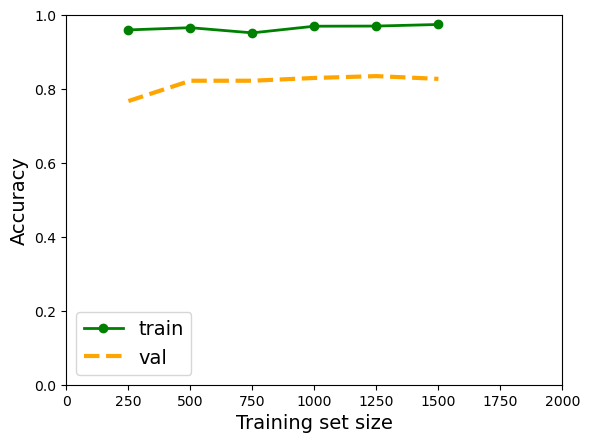

In [19]:
# Analyse de la courbe d'apprentissage sur l'échantillon
tracer_courbe_apprentissage(modele_mlp, X_echantillon, Y_echantillon)
plt.axis([0, len(X_echantillon), 0, 1])
plt.show()

In [20]:
# Recherche des meilleurs hyperparamètres avec RandomizedSearchCV
# Cette étape teste différentes configurations du réseau
def trouver_meilleurs_params(modele, X, y):
    
    # recherche des paramètres
    params_a_tester = {
        'hidden_layer_sizes': [(100,), (100, 50), (100, 50, 25)],
        'max_iter': [3000, 5000],
        'solver': ['sgd', 'adam'],
        'learning_rate': ['constant', 'adaptive'],
        'activation': ['tanh', 'relu']
    }
    
    debut = time.time()
    
    # Lancement de la recherche
    recherche = RandomizedSearchCV(
        modele, 
        params_a_tester, 
        n_jobs=-1, 
        cv=3,
        random_state=seed,
        verbose=1
    )
    recherche.fit(X, y)
    
    fin = time.time()
    
    print(f"\nTemps écoulé: {str(timedelta(seconds=fin-debut))}")
    print("\nMeilleure configuration trouvée:")
    print(recherche.best_estimator_)
    
    return recherche

In [21]:
# Optimisation sur l'ensemble complet
mlp_base = MLPClassifier(batch_size=500, random_state=seed)

print("Recherche d'hyperparamètres..")
mlp_meilleur = trouver_meilleurs_params(mlp_base, X_train_bin_processed, Y_train_bin)

Recherche d'hyperparamètres..
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Temps écoulé: 0:16:06.716894

Meilleure configuration trouvée:
MLPClassifier(batch_size=500, hidden_layer_sizes=(100, 50, 25), max_iter=3000,
              random_state=42, solver='sgd')


In [22]:
# Test du meilleur modèle sur les données de test
pred_test = mlp_meilleur.predict(X_test_bin_processed)

# Matrice de confusion
print("\nMatrice de confusion:")
mc = pd.DataFrame(
    confusion_matrix(Y_test_bin, pred_test),
    columns=['Pred: 0', 'Pred: 1'],
    index=['Vrai: 0', 'Vrai: 1']
)
print(mc)

# Rapport
print("\n" + classification_report(Y_test_bin, pred_test))


Matrice de confusion:
         Pred: 0  Pred: 1
Vrai: 0     1022      227
Vrai: 1      143      608

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1249
           1       0.73      0.81      0.77       751

    accuracy                           0.81      2000
   macro avg       0.80      0.81      0.81      2000
weighted avg       0.82      0.81      0.82      2000



In [23]:
# Passage à la classification multi-classes (3 catégories)
# Discrétisation selon les quartiles
# 3 catégories basées sur Q1 et Q3:
#    - revenus_bas (≤ Q1)
#    - revenus_moyens (Q1 < x ≤ Q3)  
#    - revenus_eleve (> Q3)

def categoriser_revenue(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    conditions = [
        (df[col] <= q1),
        (df[col] > q1) & (df[col] <= q3),
        (df[col] > q3)
    ]
    
    valeurs = ["revenus_bas", "revenus_moyens", "revenus_eleve"]
    df[col] = np.select(conditions, valeurs)
    
    return df

In [24]:
# Application de la catégorisation aux ensembles
train_multi = categoriser_revenue(ensemble_train.copy(), "revenue")
test_multi = categoriser_revenue(ensemble_test.copy(), "revenue")

print("Distribution train:")
print(train_multi["revenue"].value_counts())

print("\nDistribution test:")
print(test_multi["revenue"].value_counts())

Distribution train:
revenue
revenus_moyens    3952
revenus_bas       2060
revenus_eleve     1988
Name: count, dtype: int64

Distribution test:
revenue
revenus_moyens    994
revenus_bas       511
revenus_eleve     495
Name: count, dtype: int64


In [25]:
# Préparation X et y pour multi-classes
X_tr_multi = train_multi.drop(['revenue'], axis=1)
Y_tr_multi = train_multi['revenue']

X_te_multi = test_multi.drop(['revenue'], axis=1)
Y_te_multi = test_multi['revenue']

# Transformation
X_tr_multi_prep = pipeline_complet.fit_transform(X_tr_multi)
X_te_multi_prep = pipeline_complet.fit_transform(X_te_multi)

print(f"Shape après transformation: {X_tr_multi_prep.shape}")

Shape après transformation: (8000, 58)


C:\Users\barry\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
C:\Users\barry\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [26]:
# MLP pour 3 classes (sortie softmax implicite)
mlp_3classes = MLPClassifier(
    hidden_layer_sizes=(50,),
    solver='sgd',
    batch_size=250,
    max_iter=3000,
    activation='relu',
    random_state=6
)
print(f"Architecture: {mlp_3classes.hidden_layer_sizes}")

Architecture: (50,)


In [32]:
# Validation croisée pour multi-classes
scores_multi = cross_val_score(mlp_3classes, X_tr_multi_prep, Y_tr_multi, cv=3, scoring="accuracy")
pred_cv_multi = cross_val_predict(mlp_3classes, X_tr_multi_prep, Y_tr_multi, cv=3)

labels_classes = ["revenus_bas", "revenus_eleve", "revenus_moyens"]

print("Validation croisée - 3 classes")
print(f"Accuracy moyenne: {scores_multi.mean():.4f}")
print(f"Écart-type: {scores_multi.std():.4f}\n")

print("\nPerformances détaillées:")
print(classification_report(Y_tr_multi, pred_cv_multi, target_names=labels_classes))

Validation croisée - 3 classes
Accuracy moyenne: 0.7200
Écart-type: 0.0066


Performances détaillées:
                precision    recall  f1-score   support

   revenus_bas       0.75      0.67      0.71      2060
 revenus_eleve       0.72      0.71      0.72      1988
revenus_moyens       0.71      0.75      0.73      3952

      accuracy                           0.72      8000
     macro avg       0.73      0.71      0.72      8000
  weighted avg       0.72      0.72      0.72      8000



C:\Users\barry\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


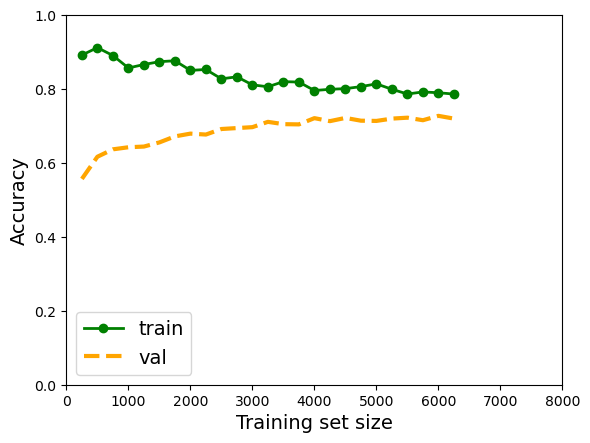

In [33]:
# Courbe d'apprentissage pour 3 classes
tracer_courbe_apprentissage(mlp_3classes, X_tr_multi_prep, Y_tr_multi)
plt.axis([0, len(X_tr_multi_prep), 0, 1])
plt.show()

In [34]:
# Optimisation hyperparamètres pour 3 classes
mlp_multi_base = MLPClassifier(batch_size=500, random_state=seed)

print("Recherche pour modèle 3 classes..")
mlp_multi_opt = trouver_meilleurs_params(mlp_multi_base, X_tr_multi_prep, Y_tr_multi)

Recherche pour modèle 3 classes..
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Temps écoulé: 0:06:43.909638

Meilleure configuration trouvée:
MLPClassifier(batch_size=500, max_iter=5000, random_state=42, solver='sgd')


In [35]:
# Test final multi-classes
pred_multi_final = mlp_multi_opt.predict(X_te_multi_prep)

print("\nMatrice de confusion:")
print(metrics.confusion_matrix(Y_te_multi, pred_multi_final))

print("\nPerformances détaillées:")
print(classification_report(Y_te_multi, pred_multi_final, target_names=labels_classes))


Matrice de confusion:
[[358   3 150]
 [  1 361 133]
 [109 124 761]]

Performances détaillées:
                precision    recall  f1-score   support

   revenus_bas       0.76      0.70      0.73       511
 revenus_eleve       0.74      0.73      0.73       495
revenus_moyens       0.73      0.77      0.75       994

      accuracy                           0.74      2000
     macro avg       0.74      0.73      0.74      2000
  weighted avg       0.74      0.74      0.74      2000



In [31]:
# Modele Binaire:
#   2 classes (≤ moyenne, > moyenne)
#   Plus simple, meilleure performance
  
# Modele multi-classes:
#   3 classes (bas, moyen, élevé)
#   Plus nuancé mais moins précis

# Conclusion:
# Le modèle binaire offre de meilleures performances car la tâche
# est moins complexe. Le modèle à 3 classes nécessiterait plus de 
# données ou un feature engineering plus poussé pour s'améliorer.

# Les courbes d'apprentissage montrent un léger surapprentissage
# dans les deux cas, avec un écart entre train et validation.